In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Display all columns
pd.set_option('display.max_columns', None)


In [3]:
df = pd.read_csv("agriculture_yield_dataset.csv")

Part A: Understanding the Dataset
Q1. Dataset Overview

a) How many rows and columns are present?

In [4]:
df.shape

(1500, 8)

b) What are the names of all columns?

In [5]:
df.columns

Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')

c) Display the first 10 records.

In [6]:
df.head(10)

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


Q2. Data Types and Missing Values

a) Check the data type of each column.

In [7]:
df.dtypes

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

b) Identify whether any missing values are present.

In [8]:
df.isnull().sum()

rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

c) If missing values exist, mention the affected columns.
Ans: No missing values are present in the dataset.

Q3. Descriptive Statistics

a) Which feature has the highest mean value?

In [9]:
df.describe()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


Ans: rainfall_mm has the highest mean value.

b) Which feature has the highest standard deviation?
Ans: rainfall_mm has the highest standard deviation.

Part B: Exploratory Data Analysis (EDA)
Q4. Distribution Analysis>
Create histograms for:

Write 2–3 observations from each histogram.

1. rainfall_mm

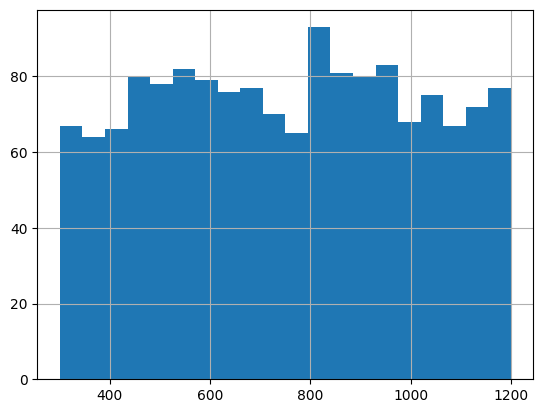

In [11]:
df['rainfall_mm'].hist(bins=20)
plt.show()

Observations:
1. Values range from about 300–1200 mm.
2. Distribution appears approximately uniform.
3. No significant outliers.


2. temperature_c

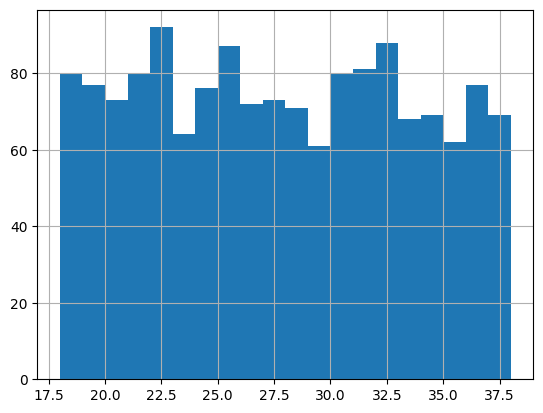

In [12]:
df['temperature_c'].hist(bins=20)
plt.show()

Observations:
1. Range: 18°C–38°C.
2. Nearly symmetric distribution.
3. No extreme values.

3. fertilizer_kg

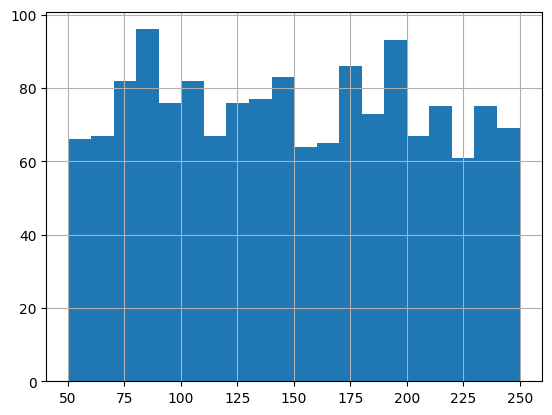

In [13]:
df['fertilizer_kg'].hist(bins=20)
plt.show()

Observations:
1. Spread is fairly even.
2. No noticeable skewness.
3. No major outliers.


4. yield_ton_per_hectare

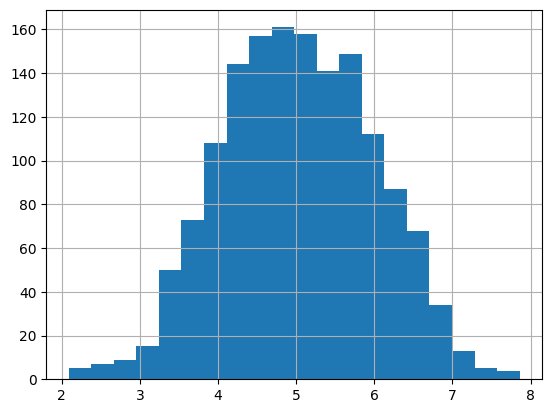

In [14]:
df['yield_ton_per_hectare'].hist(bins=20)
plt.show()

Observations:
1. Centered around 5 tons/hectare.
2. Roughly bell-shaped.
3. Few extreme values.

Q5. Crop Type Analysis

a) Find the number of records for each crop type.

In [15]:
df['crop_type'].value_counts()

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64

b) Create a count plot (bar chart) for crop_type.

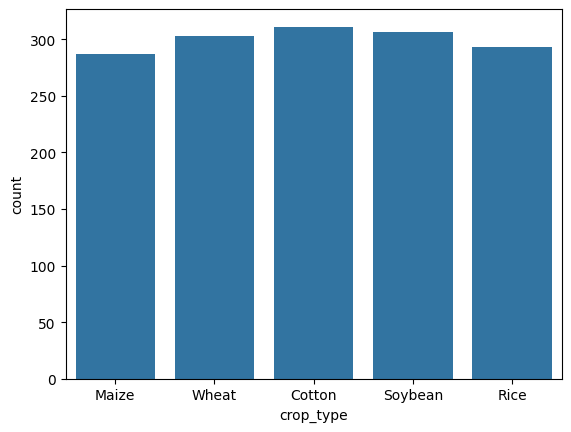

In [16]:
sns.countplot(x='crop_type', data=df)
plt.show()

c) Which crop appears most frequently?
Ans: Most Frequent Crop -> Cotton = 311 records

Q6. Soil Type Analysis

a) Find the frequency of each soil type.

In [17]:
df['soil_type'].value_counts()

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64

b) Create a count plot for soil_type.

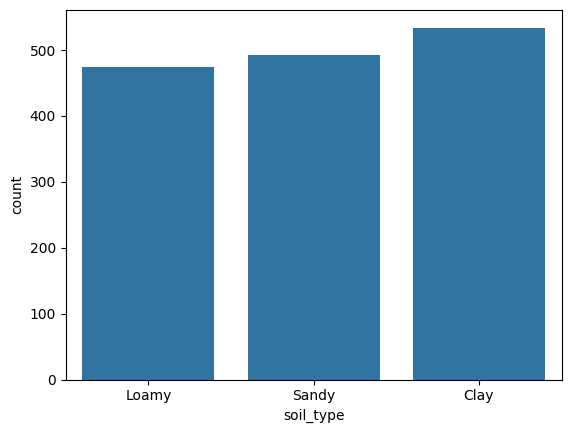

In [18]:
sns.countplot(x='soil_type', data=df)
plt.show()

c) Which soil type is most common?
Ans: Most Common Soil Type -> Clay = 534 records

Q7. Yield Distribution
Create a histogram of yield_ton_per_hectare.

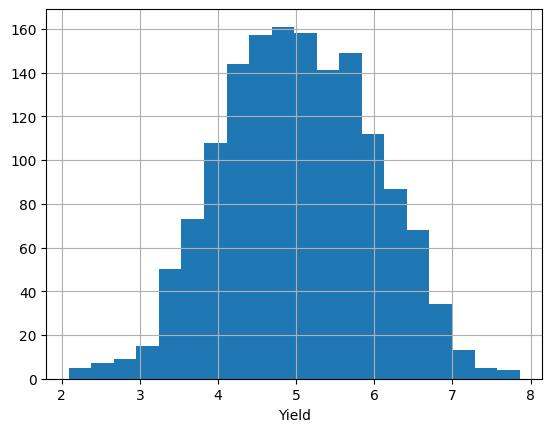

In [19]:
df['yield_ton_per_hectare'].hist(bins=20)
plt.xlabel("Yield")
plt.show()

Answers:
a) Is the distribution approximately normal?
Ans: Yes, it appears approximately normal.
b) Are there noticeable outliers?
Ans: No major outliers are visible.

Q8. Scatter Plot Analysis

1. rainfall_mm vs yield_ton_per_hectare.

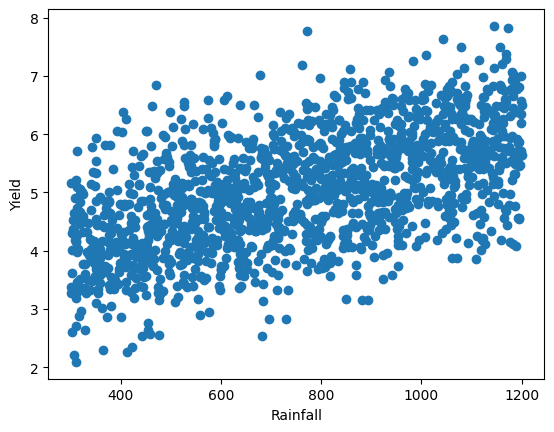

In [20]:
plt.scatter(df['rainfall_mm'],
            df['yield_ton_per_hectare'])
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.show()

2. fertilizer_kg vs yield_ton_per_hectare.

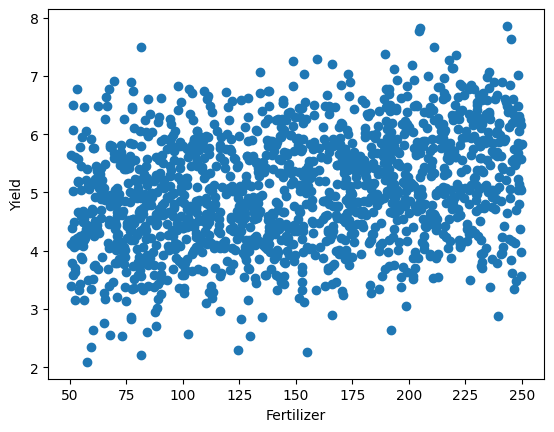

In [21]:
plt.scatter(df['fertilizer_kg'],
            df['yield_ton_per_hectare'])
plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.show()

 Q: Which feature appears to have a stronger relationship with yield?
 Ans: Rainfall has a stronger positive relationship with crop yield than fertilizer.

Q9. Correlation Analysis

a) Generate a correlation matrix for numerical features.

In [22]:
corr = df.corr(numeric_only=True)
print(corr)

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

b) Create a heatmap.

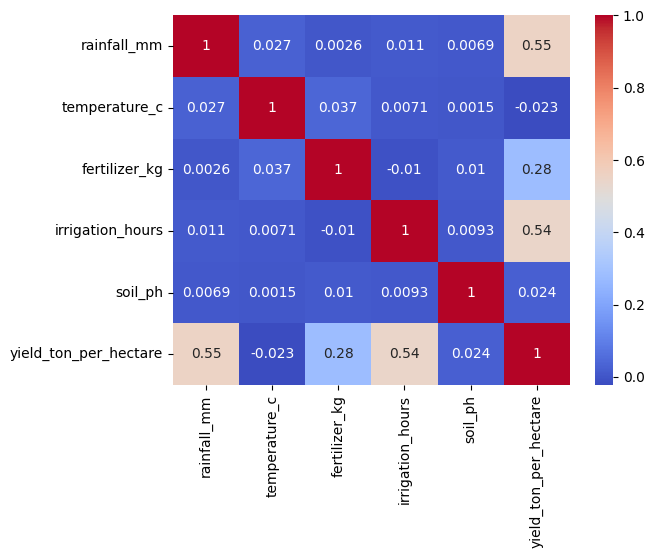

In [23]:
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')
plt.show()

c) Identify the top three features most correlated with crop yield.
Ans: 1. rainfall_mm (0.554)
     2. irrigation_hours (0.543)
     3. fertilizer_kg (0.278)

Q10. Group-Based Analysis

a) Calculate the average yield for: Each crop type

In [24]:
df.groupby('crop_type')['yield_ton_per_hectare'].mean()

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

b) Calculate the average yield for: Each soil type

In [25]:
df.groupby('soil_type')['yield_ton_per_hectare'].mean()

soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

c) Which crop and soil type have the highest average yield?
Ans: 1. Highest Average Yield Crop -> Rice
     2. Highest Average Yield Soil -> Loamy Soil

Part C: Data Preparation
Q11. Feature Encoding.

a) Identify the categorical columns.

In [26]:
['crop_type', 'soil_type']

['crop_type', 'soil_type']

b) Convert them into numerical form using One-Hot Encoding.

In [27]:
df_encoded = pd.get_dummies(
    df,
    columns=['crop_type','soil_type'],
    drop_first=True
)

c) Display the first five rows of the transformed dataset.

In [28]:
df_encoded.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


Q12. Feature Selection

1. Target Variable (y)

In [29]:
y = df_encoded['yield_ton_per_hectare']

2. Input features (X)

In [30]:
X = df_encoded.drop(
    'yield_ton_per_hectare',
    axis=1
)

In [32]:
print("X Shape:", X.shape) 
print("y Shape:", y.shape)

X Shape: (1500, 11)
y Shape: (1500,)


3. Specify which column is being used as the target variable.
ANS: Target Column -> yield_ton_per_hectare

Part D: Machine Learning
Q13. Train-Test Split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("X_train:", X_train.shape) 
print("X_test :", X_test.shape) 
print("y_train:", y_train.shape) 
print("y_test :", y_test.shape)

X_train: (1200, 11)
X_test : (300, 11)
y_train: (1200,)
y_test : (300,)


Q14. Linear Regression Model

a) Train a Linear Regression model.

In [34]:
model = LinearRegression() 
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[ 0. ,-0.01, 0. ,..., 0.35, 0.3 ,-0.49]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['rainfall_mm','temperature_c','fertilizer_kg',...,'crop_type_Wheat', 'soil_type_Loamy','soil_type_Sandy']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.587
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,11


b) Display the model coefficients and intercept.

In [35]:
#Intercept
print("Intercept:") 
print(model.intercept_)

#Coefficients
coef_df = pd.DataFrame({ 'Feature': X.columns, 'Coefficient': model.coef_ }) 
print(coef_df)

Intercept:
1.5871320277361227
              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5     crop_type_Maize     0.238931
6      crop_type_Rice     0.863993
7   crop_type_Soybean     0.481719
8     crop_type_Wheat     0.348474
9     soil_type_Loamy     0.302974
10    soil_type_Sandy    -0.490933


c) Which feature has the highest positive coefficient?

In [36]:
highest_feature = coef_df.loc[ coef_df['Coefficient'].idxmax() ] 
print("\nFeature with Highest Positive Coefficient:") 
print(highest_feature)


Feature with Highest Positive Coefficient:
Feature        crop_type_Rice
Coefficient          0.863993
Name: 6, dtype: object
